Week 3 - TensorFlow/Keras CNN
AI/ML Internship
Dataset: CIFAR-10
Framework: TensorFlow/Keras

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [5]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

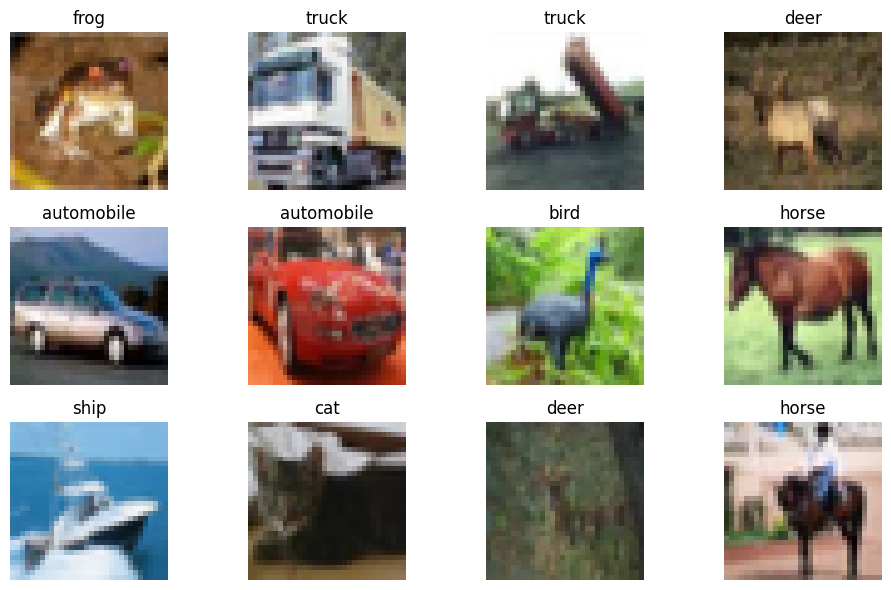

In [6]:
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [8]:
model = keras.Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(32, 32, 3)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 92ms/step - accuracy: 0.3722 - loss: 1.6954 - val_accuracy: 0.5056 - val_loss: 1.4022
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 90ms/step - accuracy: 0.5252 - loss: 1.3284 - val_accuracy: 0.5866 - val_loss: 1.1613
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 90ms/step - accuracy: 0.5838 - loss: 1.1712 - val_accuracy: 0.6354 - val_loss: 1.0434
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 88ms/step - accuracy: 0.6320 - loss: 1.0514 - val_accuracy: 0.6804 - val_loss: 0.9159
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 88ms/step - accuracy: 0.6600 - loss: 0.9716 - val_accuracy: 0.6834 - val_loss: 0.8960
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 90ms/step - accuracy: 0.6849 - loss: 0.9031 - val_accuracy: 0.6896 - val_loss: 0.8853
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.7042 - loss: 0.8487 - val_accuracy: 0.6970 - val_loss: 0.8640
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.7237 - loss: 0.7895 - 

In [12]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7039 - loss: 0.8599
Test Loss: 0.8599439263343811
Test Accuracy: 0.7038999795913696


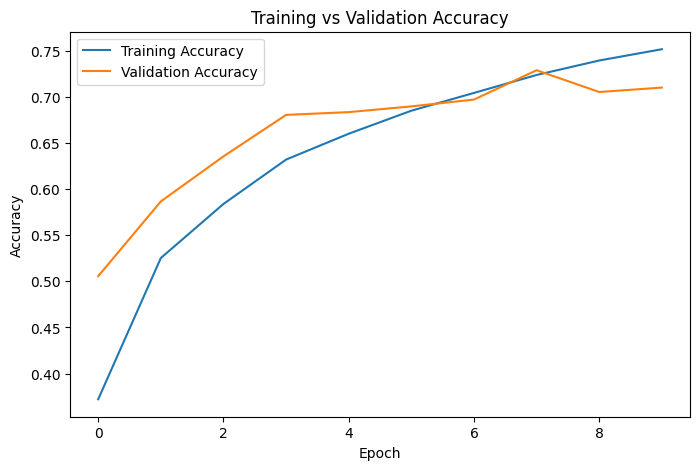

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

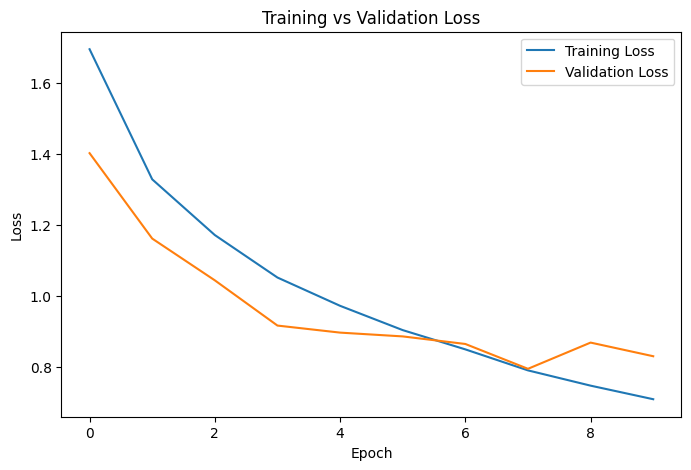

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [15]:
predictions = model.predict(x_test)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step


In [16]:
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.70      0.78      0.74      1000
  automobile       0.89      0.77      0.83      1000
        bird       0.52      0.69      0.59      1000
         cat       0.51      0.56      0.53      1000
        deer       0.68      0.63      0.65      1000
         dog       0.68      0.52      0.59      1000
        frog       0.79      0.74      0.77      1000
       horse       0.79      0.73      0.76      1000
        ship       0.75      0.86      0.80      1000
       truck       0.85      0.76      0.80      1000

    accuracy                           0.70     10000
   macro avg       0.72      0.70      0.71     10000
weighted avg       0.72      0.70      0.71     10000



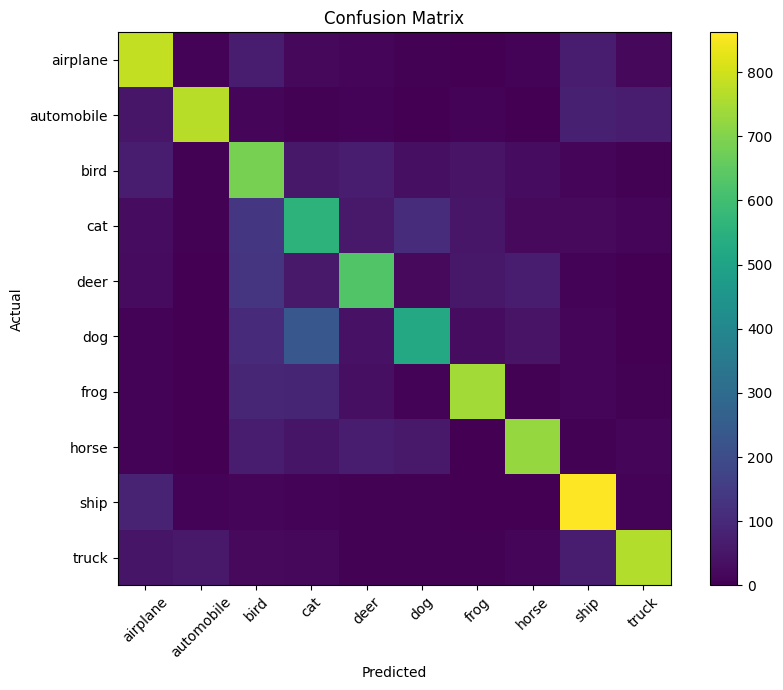

In [17]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(9, 7))

plt.imshow(cm)

plt.xticks(
    range(10),
    class_names,
    rotation=45
)

plt.yticks(
    range(10),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.tight_layout()
plt.show()

In [18]:
model.save(
    "cifar10_tensorflow_model.keras"
)